📊 RISK CATEGORIZATION ANALYSIS

📤 Please upload student_dropout_preprocessed_full.csv


Saving student_dropout_preprocessed_full.csv to student_dropout_preprocessed_full.csv

✅ Dataset loaded!
📊 Shape: 4424 students × 47 features

📋 Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 

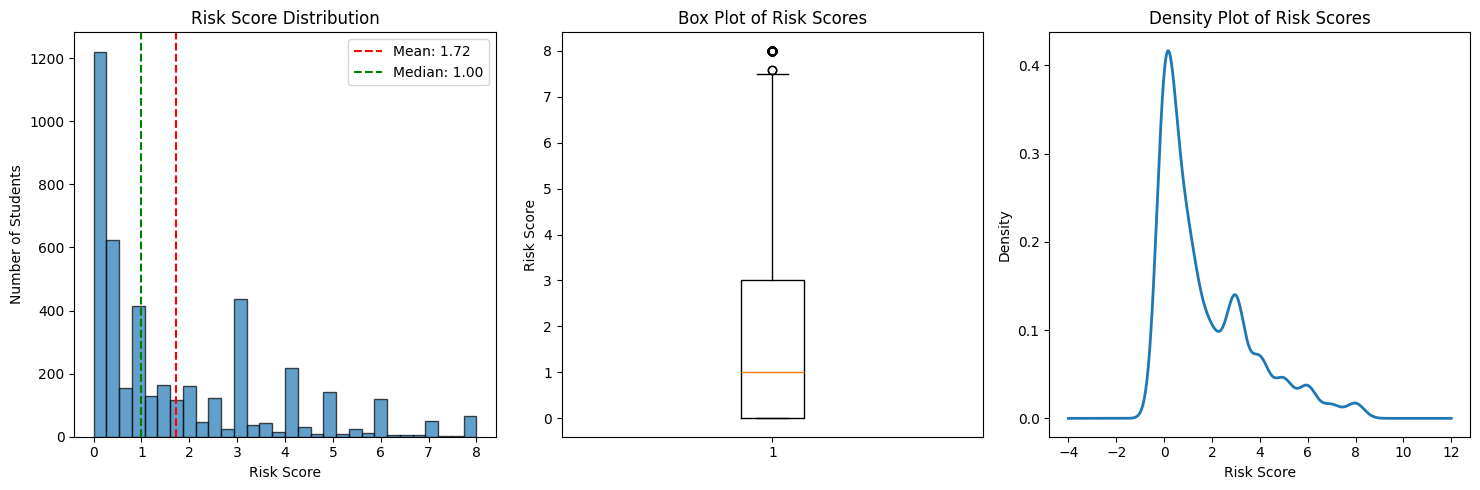

✅ Saved: risk_distribution.png

🎯 DEFINING RISK THRESHOLDS

📌 Method 1: Equal Groups (33% each)
   Low Risk: < 0.38
   Medium Risk: 0.38 - 2.00
   High Risk: > 2.00

📌 Method 2: Standard Deviation Based
   Low Risk: < 0.75
   Medium Risk: 0.75 - 2.69
   High Risk: > 2.69

📌 Dropout Rate by Initial Categories:
   Low: 4.22% dropout rate
   Medium: 17.32% dropout rate
   High: 76.07% dropout rate

⚙️ OPTIMIZING RISK THRESHOLDS

📊 Testing threshold combinations...
   Low=0.20, High=0.60 → Score: 0.608
   Low=0.20, High=0.65 → Score: 0.674
   Low=0.20, High=0.70 → Score: 0.683
   Low=0.20, High=0.75 → Score: 0.679
   Low=0.20, High=0.80 → Score: 0.679
   Low=0.25, High=0.60 → Score: 0.608
   Low=0.25, High=0.65 → Score: 0.674
   Low=0.25, High=0.70 → Score: 0.683
   Low=0.25, High=0.75 → Score: 0.679
   Low=0.25, High=0.80 → Score: 0.679
   Low=0.30, High=0.60 → Score: 0.610
   Low=0.30, High=0.65 → Score: 0.713
   Low=0.30, High=0.70 → Score: 0.717
   Low=0.30, High=0.75 → Score: 0.708
  

/tmp/ipython-input-548/1472035936.py:123: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dropout_rates = df.groupby('risk_category_temp').apply(
/tmp/ipython-input-548/1472035936.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dropout_rates = df.groupby('risk_category_temp').apply(
/tmp/ipython-input-548/1472035936.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

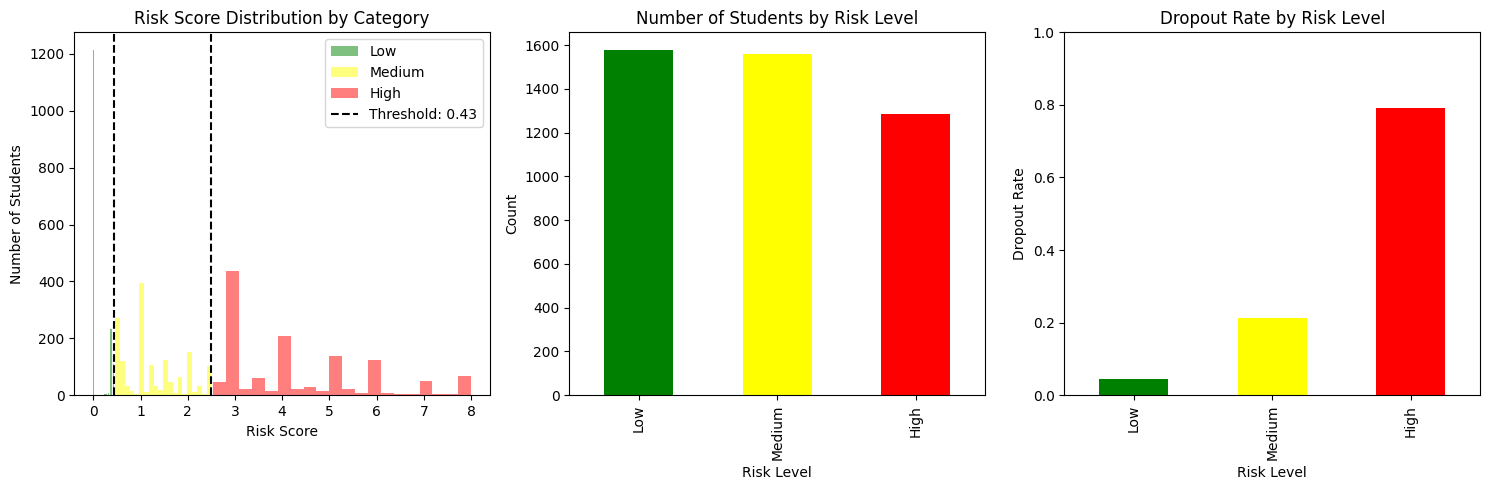


💾 SAVING RISK THRESHOLDS

✅ Saved: risk_thresholds.json
✅ Saved: student_risk_levels.csv

📋 RISK CATEGORIZATION SUMMARY

🎯 FINAL RISK THRESHOLDS:
   Low Risk:  < 0.43
   Medium Risk: 0.43 - 2.50
   High Risk: > 2.50

📊 GROUP STATISTICS:
   Low Risk:  1579 students (35.7%)
   Medium Risk: 1558 students (35.2%)
   High Risk: 1287 students (29.1%)

📈 DROPOUT RATES:
   Low Risk:  4.43%
   Medium Risk: 21.37%
   High Risk: 79.10%

✅ These thresholds will be used in the admin dashboard!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================
# RISK CATEGORIZATION & THRESHOLD OPTIMIZATION
# Author: IT24102762 - Rajakaruna R.A.R.M.O.S
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("="*60)
print("📊 RISK CATEGORIZATION ANALYSIS")
print("="*60)

# ============================================
# 1. UPLOAD YOUR DATA
# ============================================
print("\n📤 Please upload student_dropout_preprocessed_full.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ Dataset loaded!")
print(f"📊 Shape: {df.shape[0]} students × {df.shape[1]} features")
print(f"\n📋 Columns:\n{df.columns.tolist()}")

# ============================================
# 2. UNDERSTAND THE RISK SCORE
# ============================================
print("\n" + "="*60)
print("📈 ANALYZING RISK SCORE DISTRIBUTION")
print("="*60)

# Check if risk_score exists
if 'risk_score' in df.columns:
    risk_scores = df['risk_score']
else:
    # If risk_score not in data, create it
    print("\n⚠️ risk_score not found. Creating from features...")
    df['risk_score'] = (
        (1 - df['success_rate_sem2'] if 'success_rate_sem2' in df.columns else 0) * 3 +
        (1 - df['Tuition fees up to date']) * 2 +
        df['Debtor'] * 2 +
        (df['Age at enrollment'] > 25).astype(int) * 1
    )
    risk_scores = df['risk_score']

# Basic statistics
print(f"\n📊 Risk Score Statistics:")
print(f"   Minimum: {risk_scores.min():.2f}")
print(f"   Maximum: {risk_scores.max():.2f}")
print(f"   Mean: {risk_scores.mean():.2f}")
print(f"   Median: {risk_scores.median():.2f}")
print(f"   Standard Deviation: {risk_scores.std():.2f}")

# Percentiles
percentiles = [10, 25, 33, 50, 66, 75, 90]
print(f"\n📊 Percentiles:")
for p in percentiles:
    print(f"   {p}th percentile: {risk_scores.quantile(p/100):.2f}")

# Visualize distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(risk_scores, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(risk_scores.mean(), color='red', linestyle='--', label=f'Mean: {risk_scores.mean():.2f}')
plt.axvline(risk_scores.median(), color='green', linestyle='--', label=f'Median: {risk_scores.median():.2f}')
plt.xlabel('Risk Score')
plt.ylabel('Number of Students')
plt.title('Risk Score Distribution')
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot(risk_scores)
plt.ylabel('Risk Score')
plt.title('Box Plot of Risk Scores')

plt.subplot(1, 3, 3)
risk_scores.plot(kind='kde', linewidth=2)
plt.xlabel('Risk Score')
plt.ylabel('Density')
plt.title('Density Plot of Risk Scores')

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=300)
plt.show()
print("✅ Saved: risk_distribution.png")

# ============================================
# 3. DEFINE INITIAL RISK THRESHOLDS
# ============================================
print("\n" + "="*60)
print("🎯 DEFINING RISK THRESHOLDS")
print("="*60)

# Method 1: Equal Percentiles (33% each)
low_threshold_33 = risk_scores.quantile(0.33)
high_threshold_33 = risk_scores.quantile(0.66)

print(f"\n📌 Method 1: Equal Groups (33% each)")
print(f"   Low Risk: < {low_threshold_33:.2f}")
print(f"   Medium Risk: {low_threshold_33:.2f} - {high_threshold_33:.2f}")
print(f"   High Risk: > {high_threshold_33:.2f}")

# Method 2: Based on Standard Deviation
mean = risk_scores.mean()
std = risk_scores.std()
low_threshold_std = mean - 0.5*std
high_threshold_std = mean + 0.5*std

print(f"\n📌 Method 2: Standard Deviation Based")
print(f"   Low Risk: < {low_threshold_std:.2f}")
print(f"   Medium Risk: {low_threshold_std:.2f} - {high_threshold_std:.2f}")
print(f"   High Risk: > {high_threshold_std:.2f}")

# Method 3: Based on Actual Dropout Rates
df['risk_category_temp'] = pd.cut(risk_scores,
                                   bins=[-np.inf, low_threshold_33, high_threshold_33, np.inf],
                                   labels=['Low', 'Medium', 'High'])

dropout_rates = df.groupby('risk_category_temp').apply(
    lambda x: (x['Target'] == 'Dropout').mean()
)

print(f"\n📌 Dropout Rate by Initial Categories:")
for category, rate in dropout_rates.items():
    print(f"   {category}: {rate:.2%} dropout rate")

# ============================================
# 4. OPTIMIZE THRESHOLDS
# ============================================
print("\n" + "="*60)
print("⚙️ OPTIMIZING RISK THRESHOLDS")
print("="*60)

def evaluate_thresholds(low_p, high_p, risk_scores, targets):
    """
    Evaluate how good thresholds are based on:
    1. Separation of dropout rates
    2. Balanced group sizes
    """
    low_t = risk_scores.quantile(low_p)
    high_t = risk_scores.quantile(high_p)

    categories = pd.cut(risk_scores, bins=[-np.inf, low_t, high_t, np.inf],
                        labels=['Low', 'Medium', 'High'])

    # Calculate dropout rate for each category
    dropout_by_cat = []
    for cat in ['Low', 'Medium', 'High']:
        mask = categories == cat
        if mask.sum() > 0:
            rate = (targets[mask] == 'Dropout').mean()
        else:
            rate = 0
        dropout_by_cat.append(rate)

    # Score: Want low dropout in Low category, high in High category
    score = (dropout_by_cat[2] - dropout_by_cat[0])  # High minus Low

    # Also want reasonably sized groups
    size_score = 1 - abs((categories.value_counts() / len(categories)).std())

    return score * size_score

# Test different threshold combinations
best_score = -np.inf
best_low = 0.33
best_high = 0.66

print("\n📊 Testing threshold combinations...")
for low_p in np.arange(0.2, 0.4, 0.05):
    for high_p in np.arange(0.6, 0.8, 0.05):
        if low_p < high_p:
            score = evaluate_thresholds(low_p, high_p, risk_scores, df['Target'])
            print(f"   Low={low_p:.2f}, High={high_p:.2f} → Score: {score:.3f}")

            if score > best_score:
                best_score = score
                best_low = low_p
                best_high = high_p

# Final optimized thresholds
low_threshold = risk_scores.quantile(best_low)
high_threshold = risk_scores.quantile(best_high)

print(f"\n✅ OPTIMIZED THRESHOLDS:")
print(f"   Low Risk:  < {low_threshold:.2f}  (bottom {best_low:.0%} of students)")
print(f"   Medium Risk: {low_threshold:.2f} - {high_threshold:.2f}")
print(f"   High Risk: > {high_threshold:.2f}  (top {1-best_high:.0%} of students)")

# ============================================
# 5. VALIDATE FINAL THRESHOLDS
# ============================================
print("\n" + "="*60)
print("✅ VALIDATING FINAL THRESHOLDS")
print("="*60)

# Apply final thresholds
df['risk_level'] = pd.cut(risk_scores,
                           bins=[-np.inf, low_threshold, high_threshold, np.inf],
                           labels=['Low', 'Medium', 'High'])

# Group sizes
print(f"\n📊 Group Sizes:")
size_dist = df['risk_level'].value_counts()
for level, count in size_dist.items():
    print(f"   {level}: {count} students ({count/len(df)*100:.1f}%)")

# Dropout rates by risk level
print(f"\n📊 Dropout Rate by Risk Level:")
for level in ['Low', 'Medium', 'High']:
    mask = df['risk_level'] == level
    if mask.sum() > 0:
        dropout_rate = (df[mask]['Target'] == 'Dropout').mean()
        print(f"   {level}: {dropout_rate:.2%}")

# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
colors = {'Low': 'green', 'Medium': 'yellow', 'High': 'red'}
for level, color in colors.items():
    subset = df[df['risk_level'] == level]['risk_score']
    plt.hist(subset, bins=20, alpha=0.5, label=level, color=color)
plt.axvline(low_threshold, color='black', linestyle='--', label=f'Threshold: {low_threshold:.2f}')
plt.axvline(high_threshold, color='black', linestyle='--')
plt.xlabel('Risk Score')
plt.ylabel('Number of Students')
plt.title('Risk Score Distribution by Category')
plt.legend()

plt.subplot(1, 3, 2)
df['risk_level'].value_counts().plot(kind='bar', color=['green', 'yellow', 'red'])
plt.title('Number of Students by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
dropout_by_risk = df.groupby('risk_level').apply(
    lambda x: (x['Target'] == 'Dropout').mean()
)
dropout_by_risk.plot(kind='bar', color=['green', 'yellow', 'red'])
plt.title('Dropout Rate by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Dropout Rate')
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('risk_validation.png', dpi=300)
plt.show()

# ============================================
# 6. SAVE THRESHOLDS
# ============================================
print("\n" + "="*60)
print("💾 SAVING RISK THRESHOLDS")
print("="*60)

thresholds = {
    'low_risk_threshold': float(low_threshold),
    'high_risk_threshold': float(high_threshold),
    'low_percentile': float(best_low),
    'high_percentile': float(best_high),
    'method': 'optimized_based_on_dropout_rates',
    'group_sizes': {
        'low': int(size_dist['Low']),
        'medium': int(size_dist['Medium']),
        'high': int(size_dist['High'])
    },
    'dropout_rates': {
        'low': float(dropout_by_risk['Low']),
        'medium': float(dropout_by_risk['Medium']),
        'high': float(dropout_by_risk['High'])
    }
}

import json
with open('risk_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)

print(f"\n✅ Saved: risk_thresholds.json")

# Create a simple CSV with risk levels
risk_summary = df[['risk_score', 'risk_level', 'Target']].copy()
risk_summary.to_csv('student_risk_levels.csv', index=False)
print(f"✅ Saved: student_risk_levels.csv")

# ============================================
# 7. SUMMARY REPORT
# ============================================
print("\n" + "="*60)
print("📋 RISK CATEGORIZATION SUMMARY")
print("="*60)

print(f"""
🎯 FINAL RISK THRESHOLDS:
   Low Risk:  < {low_threshold:.2f}
   Medium Risk: {low_threshold:.2f} - {high_threshold:.2f}
   High Risk: > {high_threshold:.2f}

📊 GROUP STATISTICS:
   Low Risk:  {size_dist['Low']} students ({size_dist['Low']/len(df)*100:.1f}%)
   Medium Risk: {size_dist['Medium']} students ({size_dist['Medium']/len(df)*100:.1f}%)
   High Risk: {size_dist['High']} students ({size_dist['High']/len(df)*100:.1f}%)

📈 DROPOUT RATES:
   Low Risk:  {dropout_by_risk['Low']:.2%}
   Medium Risk: {dropout_by_risk['Medium']:.2%}
   High Risk: {dropout_by_risk['High']:.2%}

✅ These thresholds will be used in the admin dashboard!
""")

# Download files
files.download('risk_thresholds.json')
files.download('student_risk_levels.csv')
files.download('risk_distribution.png')
files.download('risk_validation.png')
